In [1]:
import os

for dirname, _, _ in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/wassambaig
/kaggle/input/datasets/wassambaig/datasplits
/kaggle/input/datasets/wassambaig/datasplits/dataset_split
/kaggle/input/datasets/wassambaig/datasplits/dataset_split/val
/kaggle/input/datasets/wassambaig/datasplits/dataset_split/val/Unknown
/kaggle/input/datasets/wassambaig/datasplits/dataset_split/val/Non_Aedes
/kaggle/input/datasets/wassambaig/datasplits/dataset_split/val/Aedes
/kaggle/input/datasets/wassambaig/datasplits/dataset_split/train
/kaggle/input/datasets/wassambaig/datasplits/dataset_split/train/Unknown
/kaggle/input/datasets/wassambaig/datasplits/dataset_split/train/Non_Aedes
/kaggle/input/datasets/wassambaig/datasplits/dataset_split/train/Aedes


In [2]:
!pip install -q fastai

In [3]:
from fastai.vision.all import *

In [4]:
path = Path("/kaggle/input/datasets/wassambaig/datasplits/dataset_split")

In [ ]:
dls = ImageDataLoaders.from_folder(
    path,
    train='train',
    valid='val',
    item_tfms=Resize(224),
    bs=16   
)

In [ ]:
learn = vision_learner(
    dls,
    'efficientnet_b0',   
    metrics=accuracy
)

learn = learn.to_fp16()

In [7]:
learn.fine_tune(3)

epoch,train_loss,valid_loss,accuracy,time
0,0.351318,0.255539,0.902643,01:05


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch,train_loss,valid_loss,accuracy,time
0,0.242418,0.169710,0.931415,01:16
1,0.195254,0.141644,0.944463,01:12
2,0.157701,0.132390,0.949816,01:13


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [8]:
learn.fine_tune(2)

epoch,train_loss,valid_loss,accuracy,time
0,0.222927,0.156232,0.942121,01:07


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch,train_loss,valid_loss,accuracy,time
0,0.191192,0.133902,0.947474,01:13
1,0.130066,0.131640,0.951489,01:12


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [11]:
learn.export('/kaggle/working/mosquito_classifier.pkl')

In [15]:
print(len(learn.dls.valid))

0


In [ ]:
from fastai.vision.all import *

path = Path("/kaggle/input/datasets/wassambaig/datasplits/dataset_split")

dls = ImageDataLoaders.from_folder(
    path,
    train="train",
    valid="val",
    valid_pct=None,   
    item_tfms=Resize(224),
    bs=8
)

In [17]:
print("Train size:", len(dls.train))
print("Valid size:", len(dls.valid))

Train size: 1494
Valid size: 374


In [ ]:
learn.dls = dls

In [ ]:
preds, targets = learn.get_preds(dl=dls.valid)

In [23]:
print(type(preds), type(targets))
print(len(preds), len(targets))

<class 'torch.Tensor'> <class 'torch.Tensor'>
2989 2989


In [26]:
print("TRAIN vocab:", learn.dls.vocab)

TRAIN vocab: ['Aedes', 'Non_Aedes', 'Unknown']


In [36]:
learn.dls = dls
preds, targets = learn.get_preds(dl=dls.valid)


Accuracy: 95.15%


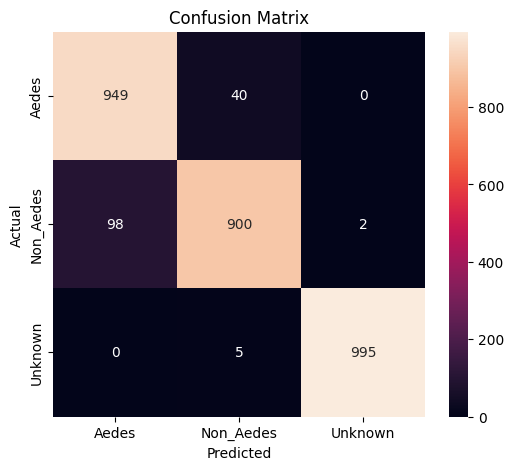


Classification Report:

              precision    recall  f1-score   support

       Aedes       0.91      0.96      0.93       989
   Non_Aedes       0.95      0.90      0.93      1000
     Unknown       1.00      0.99      1.00      1000

    accuracy                           0.95      2989
   macro avg       0.95      0.95      0.95      2989
weighted avg       0.95      0.95      0.95      2989



In [43]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Accuracy
acc = (pred_labels == true_labels).mean() * 100
print(f"\nAccuracy: {acc:.2f}%")

# Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=learn.dls.vocab,
            yticklabels=learn.dls.vocab)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Report
print("\nClassification Report:\n")
print(classification_report(true_labels, pred_labels, target_names=learn.dls.vocab))